# Playing with nnInteractive

## Dependencies, Constants, and Helper Functions

In [1]:
import os
import torch
import random
import SimpleITK as sitk
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches 

# from huggingface_hub import snapshot_download  # Install huggingface_hub if not already installed

# --- Download Trained Model Weights (~400MB) ---
REPO_ID = "nnInteractive/nnInteractive"
MODEL_NAME = "nnInteractive_v1.0"  # Updated models may be available in the future
DOWNLOAD_DIR = "/home/bhkuser/bhklab/kaitlyn/nnInteractive_test/model"  # Specify the download directory

# download_path = snapshot_download(
#     repo_id=REPO_ID,
#     allow_patterns=[f"{MODEL_NAME}/*"],
#     local_dir=DOWNLOAD_DIR
# )

# The model is now stored in DOWNLOAD_DIR/MODEL_NAME.

# --- Initialize Inference Session ---
from nnInteractive.nnInteractive.inference.inference_session import nnInteractiveInferenceSession

# Try to make reproducible 
torch.manual_seed(42) 
random.seed(42) 
np.random.seed(42)

nnUNet_raw is not defined and nnU-Net can only be used on data for which preprocessed files are already present on your system. nnU-Net cannot be used for experiment planning and preprocessing like this. If this is not intended, please read documentation/setting_up_paths.md for information on how to set this up properly.
nnUNet_preprocessed is not defined and nnU-Net can not be used for preprocessing or training. If this is not intended, please read documentation/setting_up_paths.md for information on how to set this up.
nnUNet_results is not defined and nnU-Net cannot be used for training or inference. If this is not intended behavior, please read documentation/setting_up_paths.md for information on how to set this up.


In [7]:
def find_first_last_slice(mask): 
    axes = tuple([i for i in range(mask.ndim) if i != 0])

    slices = mask.any(axis = axes) 

    nonzero_indices = np.where(slices)[0]

    first_slice = np.amin(nonzero_indices)
    last_slice = np.amax(nonzero_indices) 

    return first_slice, last_slice

## Initiate Session

In [ ]:
### Notes: do_autozoom=True results in non-deterministic segmentations which are visibly noticeable. 
### To get repeatable segmentations, set do_autozoom=False. Performance will likely drop this way though

session = nnInteractiveInferenceSession(
    device=torch.device("cpu"),  # Set inference device
    use_torch_compile=False,  # Experimental: Not tested yet
    verbose=False,
    torch_n_threads=os.cpu_count(),  # Use available CPU cores
    do_autozoom=False,  # Enables AutoZoom for better patching
    use_pinned_memory=True,  # Optimizes GPU memory transfers
)

In [3]:
# Load the trained model

model_path = os.path.join(DOWNLOAD_DIR, MODEL_NAME)
session.initialize_from_trained_model_folder(model_path)

Unable to locate trainer class nnInteractiveTrainer_stub in nnInteractive.trainer. Please place it there (in any .py file)!
Attempting to use default nnInteractiveTrainer_stub. If you encounter errors, this is where you need to look!


## Test Inference

In [4]:
# --- Load Input Image (Example with SimpleITK) ---
# DO NOT preprocess the image in any way. Give it to nnInteractive as it is! DO NOT apply level window, DO NOT normalize 
# intensities and never ever convert an image with higher precision (float32, uint16, etc) to uint8!
# The ONLY instance where some preprocesing makes sense is if your original image is too large to be reasonably used. 
# This may be the case, for example, for some microCT images. In this case you can consider downsampling.

input_image = sitk.ReadImage("/home/bhkuser/bhklab/kaitlyn/recist-vs-reality/data/procdata/Abdomen/TCIA_CPTAC-CCRCC/images/mit_CPTAC-CCRCC/C3N-00194_0035/CT_85226559/CT.nii.gz")
img = sitk.GetArrayFromImage(input_image)[None]  # Ensure shape (1, x, y, z)

# # Testing windowing: COMMENT OUT IF YOU DO NOT WANT THE IMAGE WINDOWED
# img = np.clip(img, -145, 215)

img = img.transpose(0, 2, 3, 1) # make sure that shape is transformed from (1, z, x, y) to (1, x, y, z)

# Validate input dimensions
if img.ndim != 4:
    raise ValueError("Input image must be 4D with shape (1, x, y, z)")

session.set_image(img)

# --- Define Output Buffer ---
target_tensor = torch.zeros(img.shape[1:], dtype=torch.uint8)  # Must be 3D (x, y, z)
session.set_target_buffer(target_tensor)

### Coordinate-Based Segmentation

In [ ]:
# --- Interacting with the Model ---
# Interactions can be freely chained and mixed in any order. Each interaction refines the segmentation.
# The model updates the segmentation mask in the target buffer after every interaction.
POINT_COORDINATES = (161, 231, 20)
# Example: Add a **positive** point interaction
# POINT_COORDINATES should be a tuple (x, y, z) specifying the point location.
session.add_point_interaction(POINT_COORDINATES, include_interaction=True)


In [ ]:
# --- Retrieve Results ---
# The target buffer holds the segmentation result.
results = session.target_buffer.clone()
cmap = plt.get_cmap('tab20', 0)

# Print the number of mask points created 
print(np.count_nonzero(results.numpy()))

# Plot resulting image 
plt.figure(figsize=(8,8))
plt.imshow(img[0,:,:,20], cmap = "gray")
plt.imshow(results[:, :, 20].numpy(), cmap = cmap, alpha = 0.6, interpolation = 'nearest')
plt.tight_layout() 
plt.show()

# Reset target buffer
target_tensor = torch.zeros(img.shape[1:], dtype=torch.uint8)  # Must be 3D (x, y, z)
session.set_target_buffer(target_tensor)

In [ ]:
# Example: Add a **negative** point interaction
# To make any interaction negative set include_interaction=False
session.add_point_interaction(POINT_COORDINATES, include_interaction=False)

### Using Bounding Box

In [ ]:
# Reset target buffer and interactions
session.set_target_buffer(torch.zeros(img.shape[1:], dtype=torch.uint8))
session.reset_interactions()
# Example: Add a bounding box interaction
# BBOX_COORDINATES must be specified as [[x1, x2], [y1, y2], [z1, z2]] (half-open intervals).
# Note: nnInteractive pre-trained models currently only support **2D bounding boxes**.
# This means that **one dimension must be [d, d+1]** to indicate a single slice.
BBOX_COORDINATES = [[212, 381], [293, 425], [29, 30]] #These are actually [[y1, y2], [x1, x2], [z1, z2]]??

# Example of a 2D bounding box in the axial plane (XY slice at depth Z)
# BBOX_COORDINATES = [[30, 80], [40, 100], [10, 11]]  # X: 30-80, Y: 40-100, Z: slice 10

session.add_bbox_interaction(BBOX_COORDINATES, include_interaction=True)

# --- Retrieve Results ---
# The target buffer holds the segmentation result.
results = session.target_buffer.clone()
results = np.ma.masked_where(results.numpy() == 0, results)

In [ ]:
%matplotlib inline 
cmap = plt.get_cmap('tab20', 1)

# Print the number of mask points created 
print(np.count_nonzero(results))
# bbox = patches.Rectangle((293, 212), 132, 169, linewidth = 2, edgecolor='red', facecolor=None)

# Plot resulting image 
fig, ax = plt.subplots(figsize=(8,8))
ax.imshow(img[0,:,:,35], cmap = "gray")
ax.imshow(results[:, :, 35], cmap = cmap, alpha = 0.4, interpolation = 'nearest')
# ax.add_patch(bbox)
plt.tight_layout() 
plt.show()

# Reset target buffer
target_tensor = torch.zeros(img.shape[1:], dtype=torch.uint8)  # Must be 3D (x, y, z)
session.set_target_buffer(target_tensor)

In [ ]:
def find_first_last_slice(mask): 
    axes = tuple([i for i in range(mask.ndim) if i != 0])

    slices = mask.any(axis = axes) 

    nonzero_indices = np.where(slices)[0]

    first_slice = np.amin(nonzero_indices)
    last_slice = np.amax(nonzero_indices) 

    return first_slice, last_slice

In [ ]:
npz_info = np.load('/home/bhkuser/bhklab/kaitlyn/recist-vs-reality/data/procdata/Abdomen/TCIA_CPTAC-CCRCC/images/npz_TCIA_CPTAC-CCRCC/C3N-00194_0035_RTSTRUCT_210218.4_0.npz')

# Making the positive negative visualization 
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches 
import math 
# Make the predicted mask a different number to represent a different colour 
mask_alt = results * 2 

# Add masks together so that false negative is 1, false positive is 2, and true positive is 3 
comb_masks_arr = mask_alt + npz_info['gts'].transpose(1, 2, 0)
comb_masks = np.ma.masked_where(comb_masks_arr == 0, comb_masks_arr)

# Find the first and last slices that have mask in them 
gt_min, gt_max = find_first_last_slice(npz_info['gts'])
# pred_min, pred_max = find_first_last_slice(mask_preds) 

num_nonzero_slices = gt_max - gt_min + 1 # need to add one to get true number. e.g. slices 0 - 5 have non zero (inclusive), true answer is 6 slices, but subtraction only will yield 5
# Check to see if there are more than 5 slices within the ground truth mask and adjust the subplot information accordingly 
if num_nonzero_slices < 5: 
    subplot_slices = num_nonzero_slices
else: 
    subplot_slices = 5

# slices_to_plot = [pred_min, gt_min, gt_min + math.floor(num_nonzero_slices/4), gt_min + math.floor(num_nonzero_slices/2), gt_min + math.floor(num_nonzero_slices * 3 / 4), gt_max, pred_max]
slices_to_plot = [gt_min, gt_min + math.floor(num_nonzero_slices/4), gt_min + math.floor(num_nonzero_slices/2), gt_min + math.floor(num_nonzero_slices * 3 / 4), gt_max]
print(slices_to_plot)
# Plot the five most middle slices to the segmentation and overlay them on top of the original image
fig, axes = plt.subplots(1, 5, figsize = (15, 4)) 

# Create colour map for mask 
colours = ['red', 'green', 'blue']
boundaries = [1, 2, 3, 4]
cmap = mcolors.ListedColormap(colours)
norm = mcolors.BoundaryNorm(boundaries, cmap.N)

# Make legend info 
legend_elem = [mpatches.Patch(color = 'red', label = 'False Negative'), 
               mpatches.Patch(color = 'green', label = 'False Positive'), 
               mpatches.Patch(color = 'blue', label = 'True Positive')]
counter = 0
for i in slices_to_plot: 
    axes[counter].imshow(img[0,:,:,i], cmap = 'gray') 
    axes[counter].imshow(comb_masks[:,:,i], cmap = cmap, norm = norm, interpolation = 'nearest', alpha = 0.6)
    axes[counter].axis("off")
    axes[counter].text(0.5, -0.1, f"Slice {i}", size =11, ha="center", transform = axes[counter].transAxes)
    counter += 1
    plt.tight_layout()

fig.legend(handles = legend_elem, loc = 'lower right', bbox_to_anchor=(0.67, -0.10), ncol=3, frameon=False, fontsize=11)
plt.show()

### Scribble (AKA Lines)

In [5]:
# Example: Add a scribble interaction
# - A 3D image of the same shape as img where one slice (any axis-aligned orientation) contains a hand-drawn scribble.
# - Background must be 0, and scribble must be 1.
# - Use session.preferred_scribble_thickness for optimal results.

# Reset target buffer and interactions
session.set_target_buffer(torch.zeros(img.shape[1:], dtype=torch.uint8))
session.reset_interactions()

npz_info = np.load('/home/bhkuser/bhklab/kaitlyn/recist-vs-reality/data/procdata/Abdomen/TCIA_CPTAC-CCRCC/images/npz_TCIA_CPTAC-CCRCC/C3N-00194_0035_RTSTRUCT_210218.4_0.npz')
recist_scrib = npz_info['recist'].transpose(1, 2, 0)
session.add_scribble_interaction(recist_scrib, include_interaction=True)

# --- Retrieve Results ---
# The target buffer holds the segmentation result.
results = session.target_buffer.clone()
results = np.ma.masked_where(results.numpy() == 0, results)

Added new image interaction: scale 1, center [[282, 351, 44]]
Took 18.106 s for initial prediction at zoom out factor 1
No zoom out necessary
No refinement necessary
Done. Total time 18.116s


435898


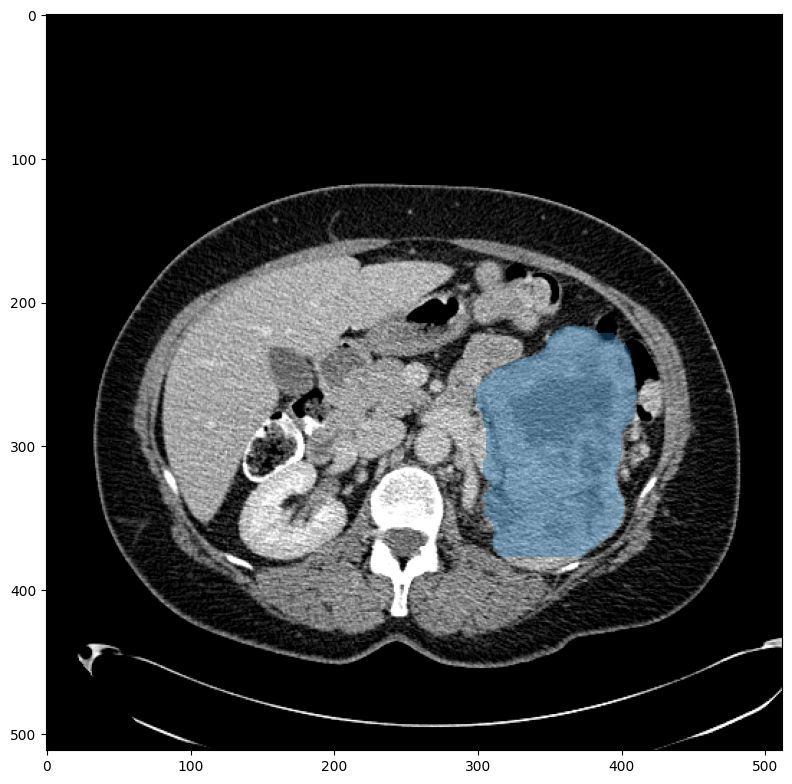

In [6]:
%matplotlib inline 
cmap = plt.get_cmap('tab20', 1)

# Print the number of mask points created 
print(np.count_nonzero(results))
# bbox = patches.Rectangle((293, 212), 132, 169, linewidth = 2, edgecolor='red', facecolor=None)

# Plot resulting image 
fig, ax = plt.subplots(figsize=(8,8))
ax.imshow(np.clip(img[0,:,:,35],-135, 215), cmap = "gray")
ax.imshow(results[:, :, 35], cmap = cmap, alpha = 0.4, interpolation = 'nearest')
# ax.add_patch(bbox)
plt.tight_layout() 
plt.show()

# Reset target buffer
target_tensor = torch.zeros(img.shape[1:], dtype=torch.uint8)  # Must be 3D (x, y, z)
session.set_target_buffer(target_tensor)

11 57
[np.int64(13), np.int64(22), np.int64(32), np.int64(41), np.int64(50)]


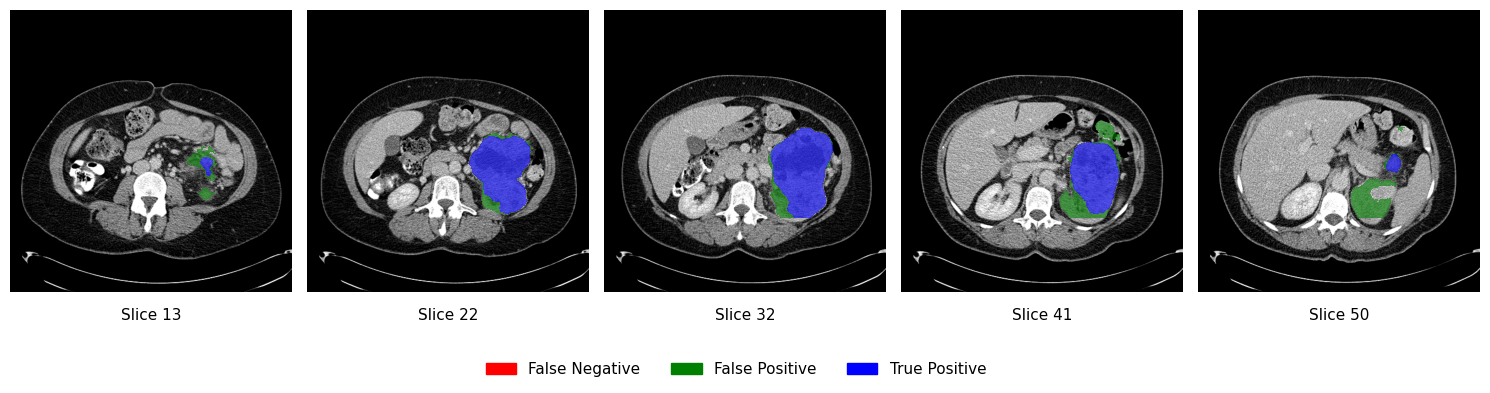

In [8]:
# Making the positive negative visualization 
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches 
import math 
%matplotlib inline
# Make the predicted mask a different number to represent a different colour 
mask_alt = results * 2 

# Add masks together so that false negative is 1, false positive is 2, and true positive is 3 
comb_masks_arr = mask_alt + npz_info['gts'].transpose(1, 2, 0)
comb_masks = np.ma.masked_where(comb_masks_arr == 0, comb_masks_arr)

# Find the first and last slices that have mask in them 
gt_min, gt_max = find_first_last_slice(npz_info['gts'])
pred_min, pred_max = find_first_last_slice(results.transpose(2, 0, 1))
print(pred_min, pred_max)
# pred_min, pred_max = find_first_last_slice(mask_preds) 

num_nonzero_slices = gt_max - gt_min + 1 # need to add one to get true number. e.g. slices 0 - 5 have non zero (inclusive), true answer is 6 slices, but subtraction only will yield 5
# Check to see if there are more than 5 slices within the ground truth mask and adjust the subplot information accordingly 
if num_nonzero_slices < 5: 
    subplot_slices = num_nonzero_slices
else: 
    subplot_slices = 5

# slices_to_plot = [pred_min, gt_min, gt_min + math.floor(num_nonzero_slices/4), gt_min + math.floor(num_nonzero_slices/2), gt_min + math.floor(num_nonzero_slices * 3 / 4), gt_max, pred_max]
slices_to_plot = [gt_min, gt_min + math.floor(num_nonzero_slices/4), gt_min + math.floor(num_nonzero_slices/2), gt_min + math.floor(num_nonzero_slices * 3 / 4), gt_max]
print(slices_to_plot)
# Plot the five most middle slices to the segmentation and overlay them on top of the original image
fig, axes = plt.subplots(1, 5, figsize = (15, 4)) 

# Create colour map for mask 
colours = ['red', 'green', 'blue']
boundaries = [1, 2, 3, 4]
cmap = mcolors.ListedColormap(colours)
norm = mcolors.BoundaryNorm(boundaries, cmap.N)

# Make legend info 
legend_elem = [mpatches.Patch(color = 'red', label = 'False Negative'), 
               mpatches.Patch(color = 'green', label = 'False Positive'), 
               mpatches.Patch(color = 'blue', label = 'True Positive')]
counter = 0
for i in slices_to_plot: 
    axes[counter].imshow(np.clip(img[0,:,:,i], -135, 215), cmap = 'gray') 
    axes[counter].imshow(comb_masks[:,:,i], cmap = cmap, norm = norm, interpolation = 'nearest', alpha = 0.6)
    axes[counter].axis("off")
    axes[counter].text(0.5, -0.1, f"Slice {i}", size =11, ha="center", transform = axes[counter].transAxes)
    counter += 1
    plt.tight_layout()

fig.legend(handles = legend_elem, loc = 'lower right', bbox_to_anchor=(0.67, -0.10), ncol=3, frameon=False, fontsize=11)
plt.show()